# Experimento 02

## Adaptación de la primera capa de convolución para dar más importancia al eje frecuencial

In [1]:
%%capture
from framework.framework_final import Persister, MetricsCalculator, AudioResNetModel, GSC, Preprocessor, Trainer, Evaluator, prepare_batch, plot_curves, show_image_grid, signal_grad_cam_overlays2d
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from typing import List, Dict, Any, Optional
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from signal_grad_cam.pytorch_cam_builder import TorchCamBuilder

I0000 00:00:1780887834.002619    1885 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780887834.033597    1885 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780887834.853856    1885 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780887834.854115    1885 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
AUDIO_PATH = Path('/mnt/data/GSC/normalized-dataset')
XTRAIN_PATH = Path('./dataframes/FASE2-X_train.csv')
XTEST_PATH = Path('./dataframes/FASE2-X_test.csv')
XVAL_PATH = Path('./dataframes/FASE2-X_val.csv')
YVAL_PATH = Path('./dataframes/FASE2-y_val.csv')
YTRAIN_PATH = Path('./dataframes/FASE2-y_train.csv')
YTEST_PATH = Path('./dataframes/FASE2-y_test.csv')
BACKGROUND_NOISES = sorted(Path(f"/mnt/data/GSC/speech_commands_v0.02/_background_noise_/").glob('*wav'))

NUM_CLASSES = 35

DEVICE = 'cuda'

# Cambios MELs
SAMPLE_RATE = 16000
N_MELS =128
N_FFT = int(768)
WIN_LENGTH = N_FFT
HOP_LENGTH = int(100)

In [3]:
final_path = '02-experimento_02/final'
checkpoints_path = '02-experimento_02/checkpoints'
xai_path = Path('/mnt/data/GSC/XAI/02-experimento_02')
batch_size = 56
epochs = 10

In [4]:
%%capture
# Instanciación del framework
persister = Persister(final_path=final_path, checkpoints_path=checkpoints_path, xai_path=xai_path)
preprocessor_train = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,
        with_log = True,
        device = DEVICE,
        mode = "training")

preprocessor_test = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,    
        with_log = True,
        device = DEVICE)
# Modelo
model = AudioResNetModel(dims=2, num_classes=NUM_CLASSES).get_model()
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7,3), stride=(1,1), padding=(3,1))
model.to(DEVICE)

In [5]:
# Conjuntos de datos
X_train = pd.read_csv(XTRAIN_PATH)
X_test = pd.read_csv(XTEST_PATH)
y_train = pd.read_csv(YTRAIN_PATH)
y_test = pd.read_csv(YTRAIN_PATH)
X_val = pd.read_csv(XVAL_PATH)                                                                                                          
y_val = pd.read_csv(YVAL_PATH)                                                                                                          

le = LabelEncoder()

y_encoded = le.fit_transform(y_train['keyword'])
ytest_encoded = le.transform(y_test['keyword'])
yval_encoded = le.transform(y_val['keyword'])

label_names= le.classes_

train_list = X_train['path_normalized'].tolist()                                                                                            
train_labels = y_encoded.tolist() 
val_list = X_val['path_normalized'].tolist()                                                                                            
val_labels = yval_encoded.tolist() 
test_list = X_test['path_normalized'].tolist()
test_labels = ytest_encoded.tolist()

train_dataset = GSC(file_list=train_list, labels=train_labels)
validation_dataset = GSC(file_list=val_list, labels=val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=prepare_batch, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=prepare_batch, num_workers=4)
test_dataset = GSC(test_list, test_labels)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 4)

In [6]:
trainer = Trainer(model=model, train_loader=train_loader, val_loader=val_loader, preprocessor=preprocessor_train, persister=persister, device=DEVICE, epochs=5)                        
trainer.fit(resume=False)

Epoch::   0%|          | 0/5 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/1323 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/189 [00:00<?, ?it/s]

Epoch 1/5
  Train - Pérdida: 0.6966, Accuracy: 0.8001, F1-score: 0.7913
  Val   - Pérdida: 0.6376, Accuracy: 0.8119, F1-score: 0.8090


Batches entrenamiento:   0%|          | 0/1323 [00:00<?, ?it/s]

...

Batches validación:   0%|          | 0/189 [00:00<?, ?it/s]

Epoch 4/5
  Train - Pérdida: 0.1517, Accuracy: 0.9526, F1-score: 0.9485
  Val   - Pérdida: 0.2820, Accuracy: 0.9194, F1-score: 0.9126


Batches entrenamiento:   0%|          | 0/1323 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/189 [00:00<?, ?it/s]

Epoch 5/5
  Train - Pérdida: 0.1261, Accuracy: 0.9598, F1-score: 0.9565
  Val   - Pérdida: 0.2227, Accuracy: 0.9364, F1-score: 0.9306


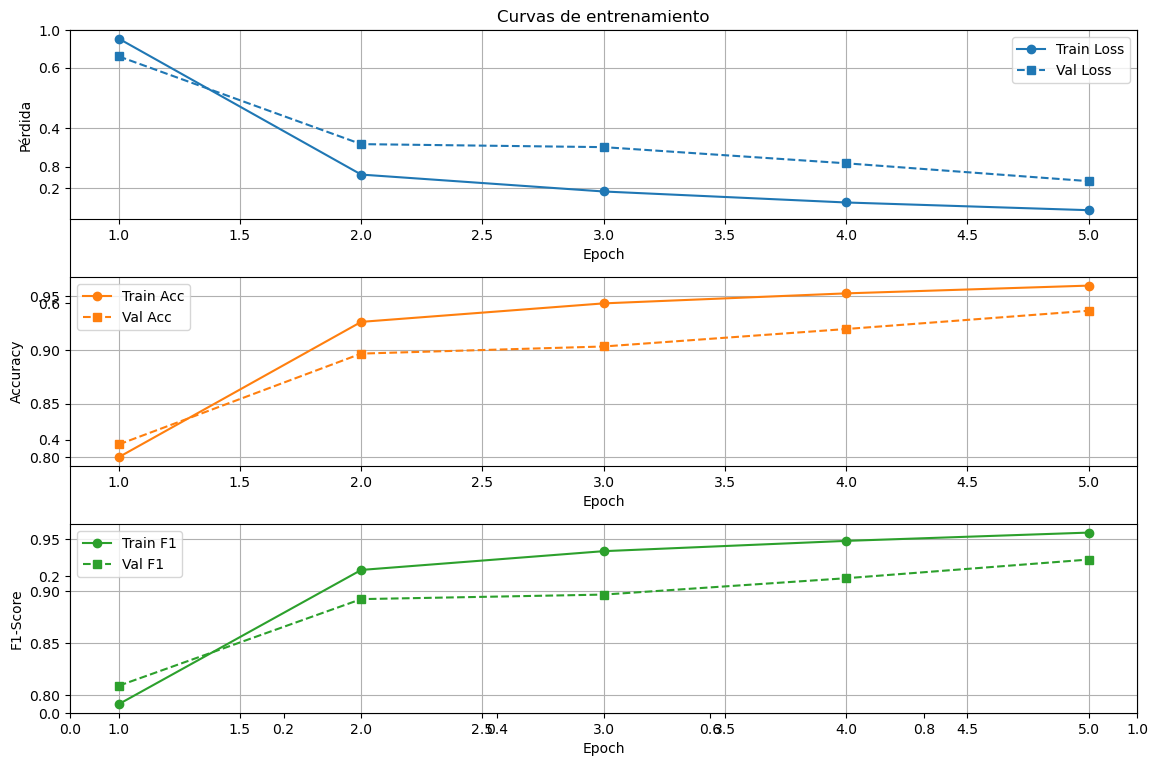

In [9]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.conv1 = nn.Conv2d(1, 64, kernel_size=(7,3), stride=(1,1), padding=(3,1))
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

plot_curves(loaded_pt, 'Curvas de entrenamiento')

**Análisis del entrenamiento**

Vemos en la evolución de la métrica de validación que las curvas de entrenamiento mejoran ligeramente con respecto a la línea de base, y el modelo que parece tener mejor métrica en este caso es el final, sobre el que visualizaremos los datos. **Aunque sólo se han entrenado 5 epochs pareceque Parece que las curvas** 

In [10]:
# Instanciamos el evaluador y computamos métricas
evaluator = Evaluator(model=loaded_model, device=DEVICE, test_loader=test_loader, preprocessor = preprocessor_test)
confusion_matrix, precission, recall, avg_loss, accuracy, f1, support = evaluator.eval()
print("Pérdida:", avg_loss, "Accuracy:", accuracy, "F1-Score:", f1)

Batches evaluación:   0%|          | 0/189 [00:00<?, ?it/s]

Pérdida: 0.5933889947994604 Accuracy: 0.9114534114534114 F1-Score: 0.9066234262935693


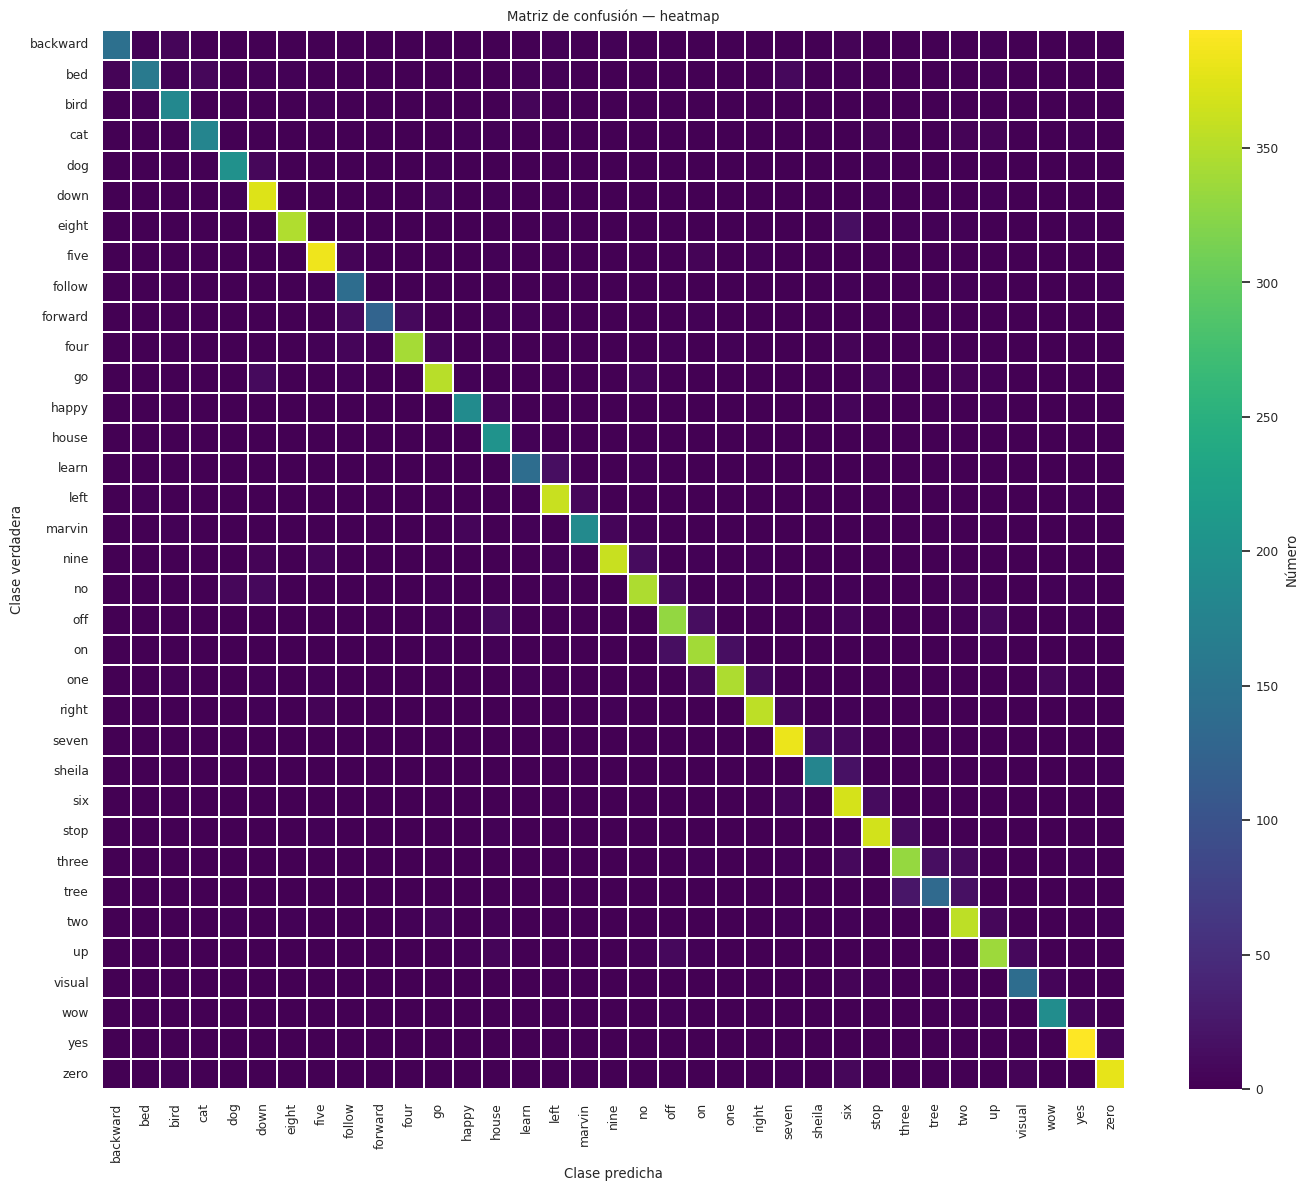

In [11]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize = (14,12))
sb.set(font_scale = 0.8)
ax = sb.heatmap(confusion_matrix,
                annot=False,
                fmt = ".2f",
                cmap = "viridis",
                cbar_kws = {"label": "Número"},
                xticklabels = label_names,
                yticklabels = label_names,
                linewidths = 0.3,
                linecolor = "white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Matriz de confusión — heatmap")
plt.tight_layout()
plt.show()
plt.rcdefaults()

No se aprecia ninguna clase especialmente problemática.

In [12]:
print("Accuracy:", accuracy, "Precission:", precission, "Recall:", recall, "Pérdida media:", avg_loss, "F1-score:", f1)

Accuracy: 0.9114534114534114 Precission: 0.9126050907210351 Recall: 0.9031041339258372 Pérdida media: 0.5933889947994604 F1-score: 0.9066234262935693


In [13]:
## Signal_grad_cam: Preparamos los datos
reference_samples = ['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav']
reference_labels = [11,19,15]

reference_dataset = GSC(reference_samples, reference_labels)
reference_loader = DataLoader(reference_dataset, batch_size = 3, shuffle = False, 
                              collate_fn = prepare_batch, num_workers = 4)

reference_targets = [11,19,15]

In [14]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "Grad-CAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

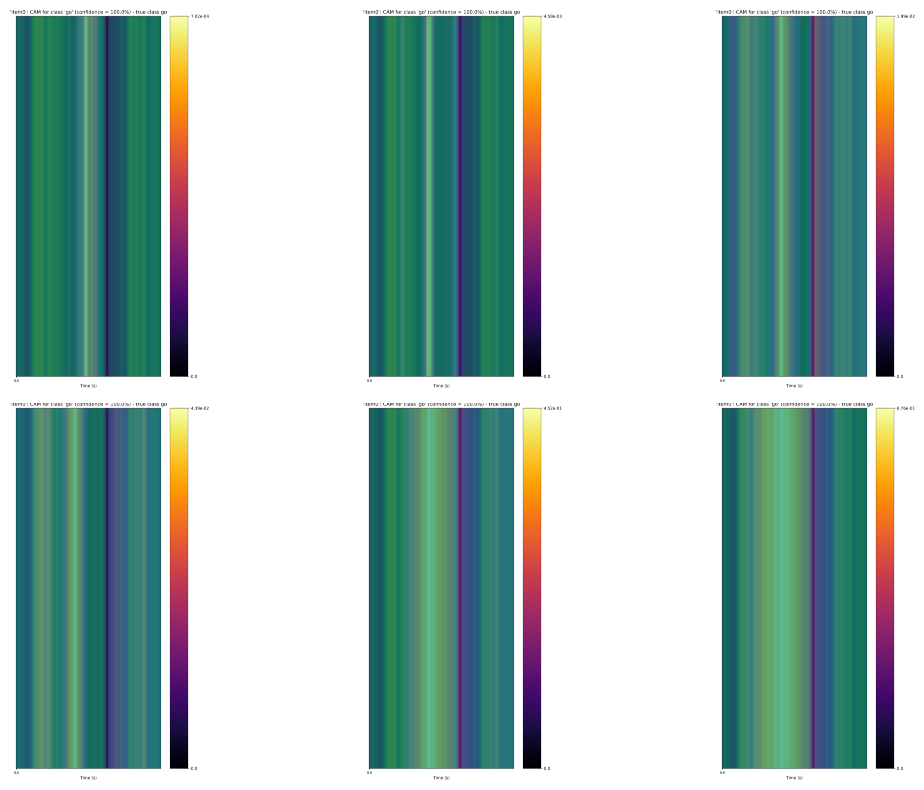

In [15]:
## Visualizamos muestra de capas
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*Grad*.png"))
show_image_grid(images_to_show)

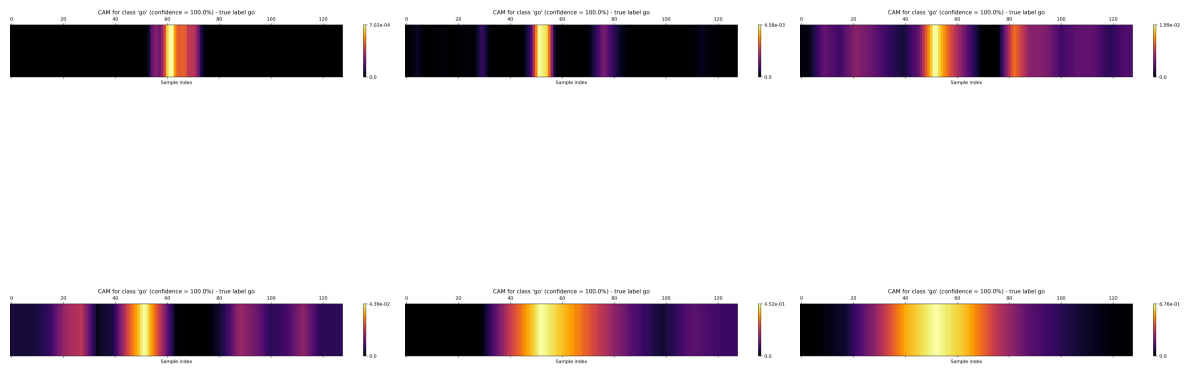

In [16]:
## Visualizamos sólo las CAMs
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/0-2/item0/").glob("*Grad-CAM*11.png"))
show_image_grid(images_to_show)

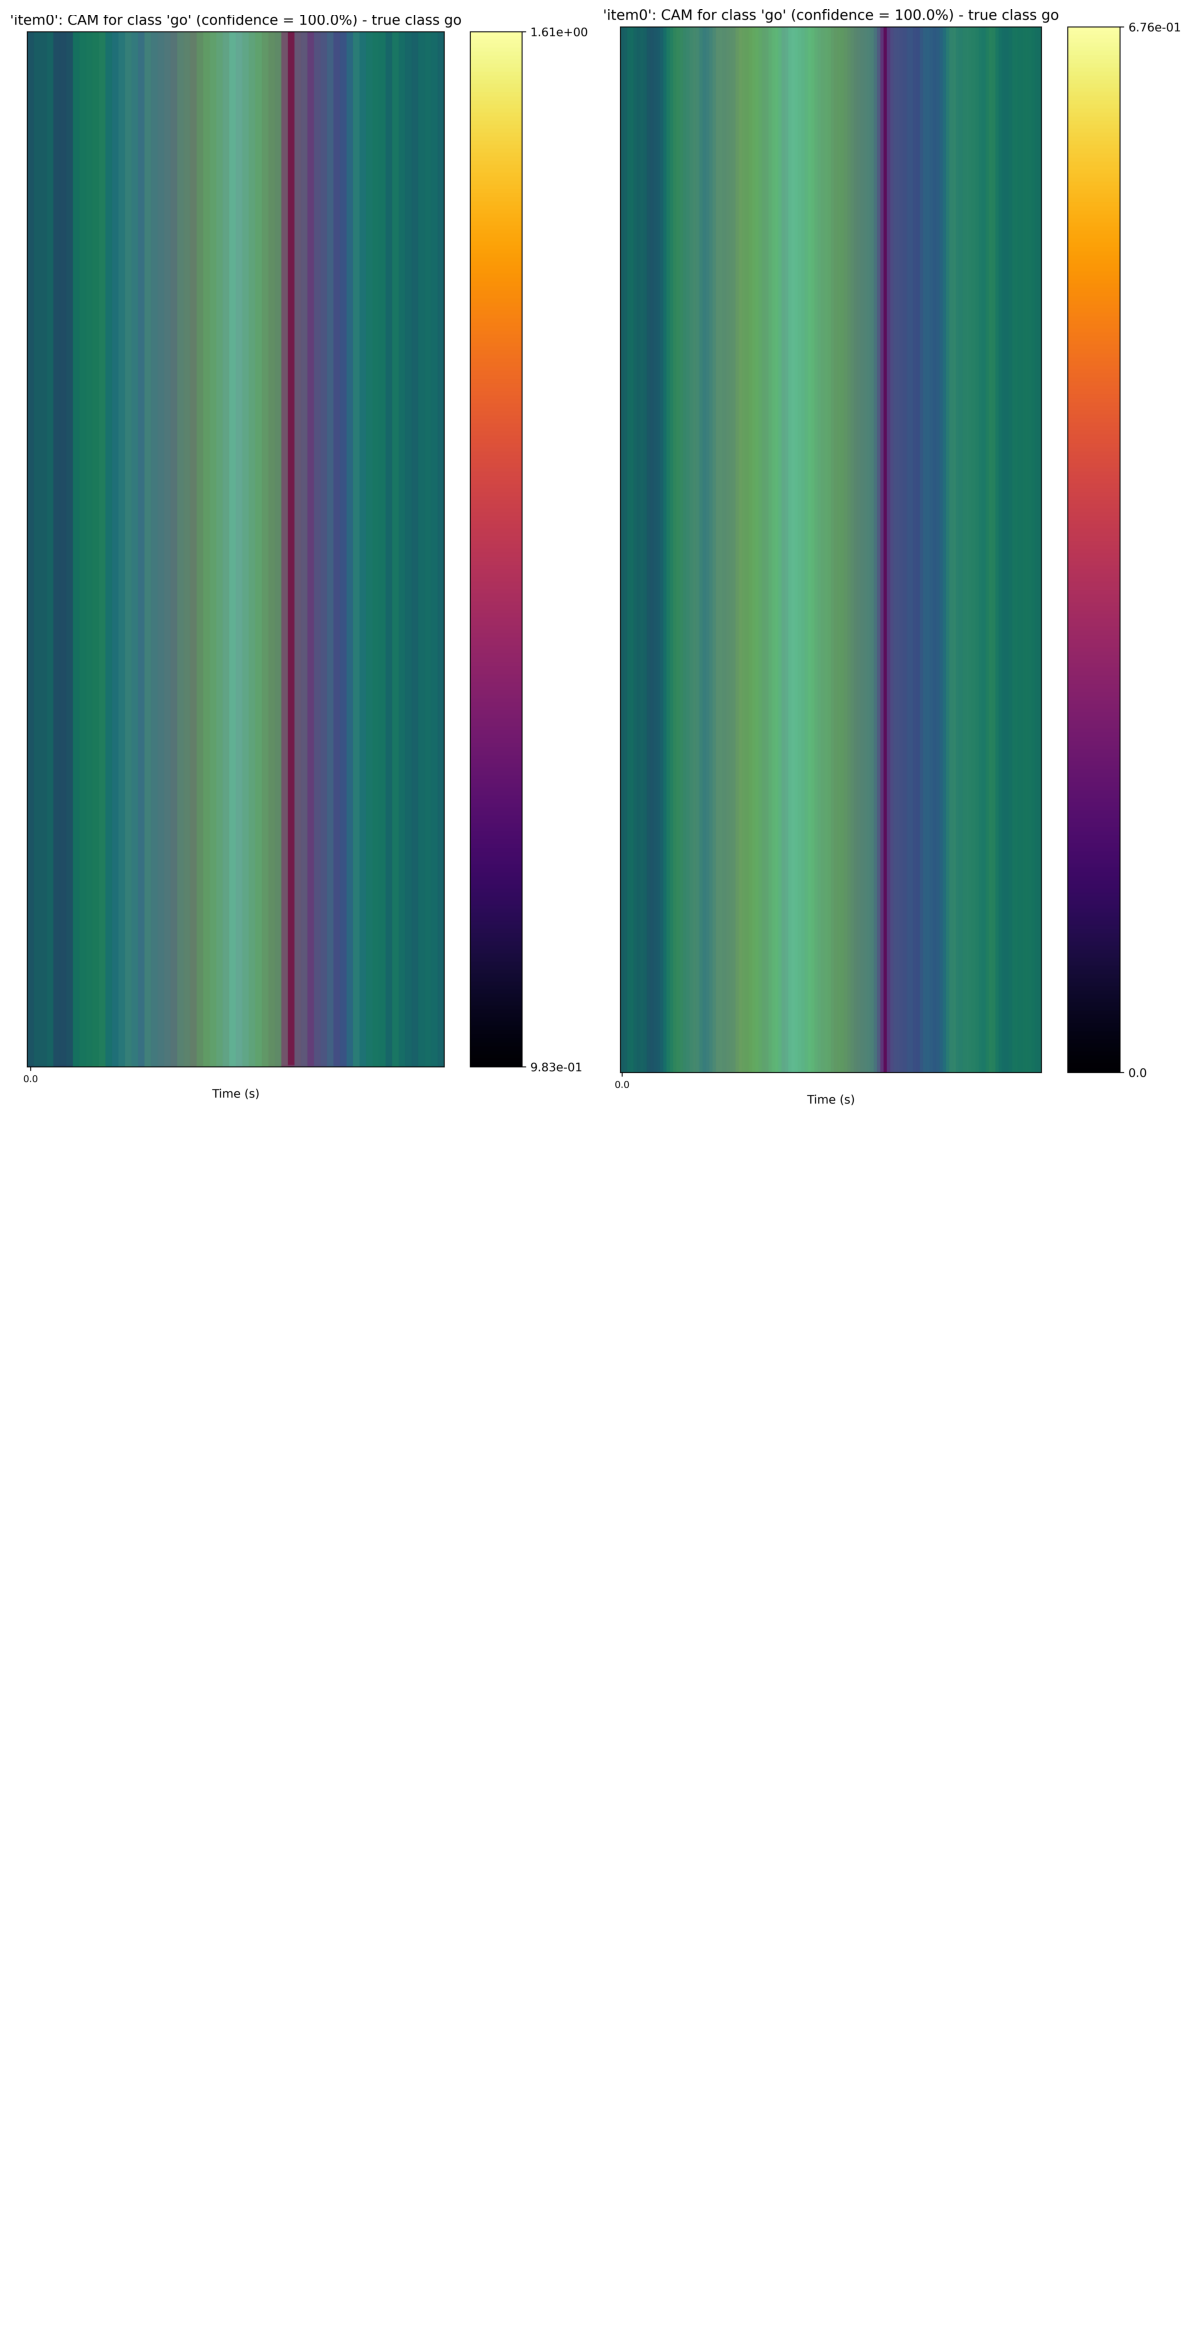

In [17]:
# CAM "GO"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

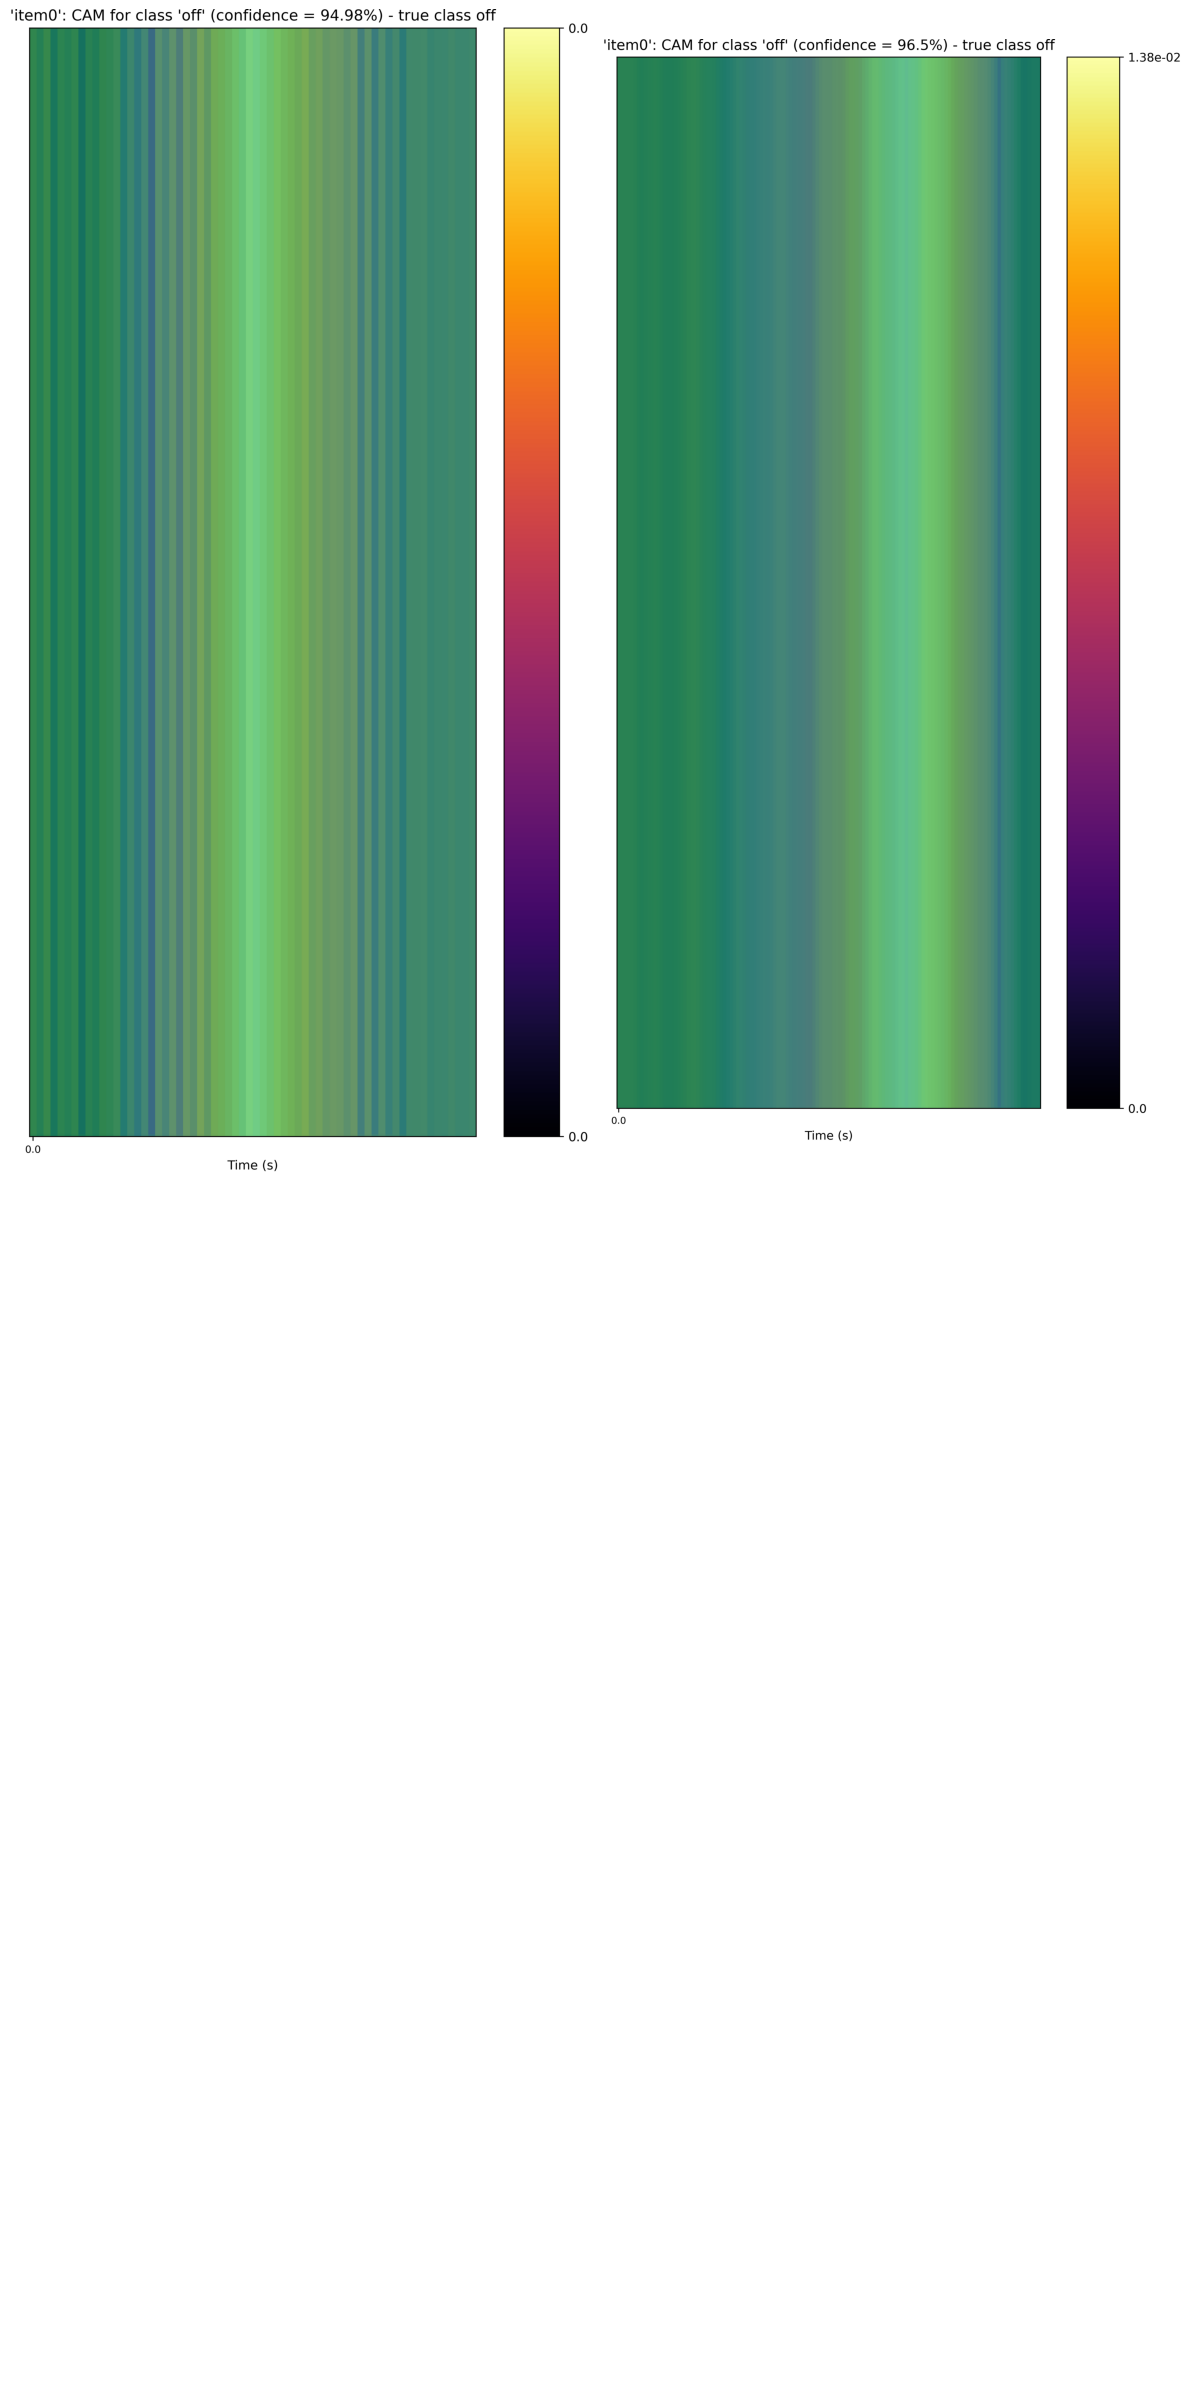

In [18]:
# CAM "OFF"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

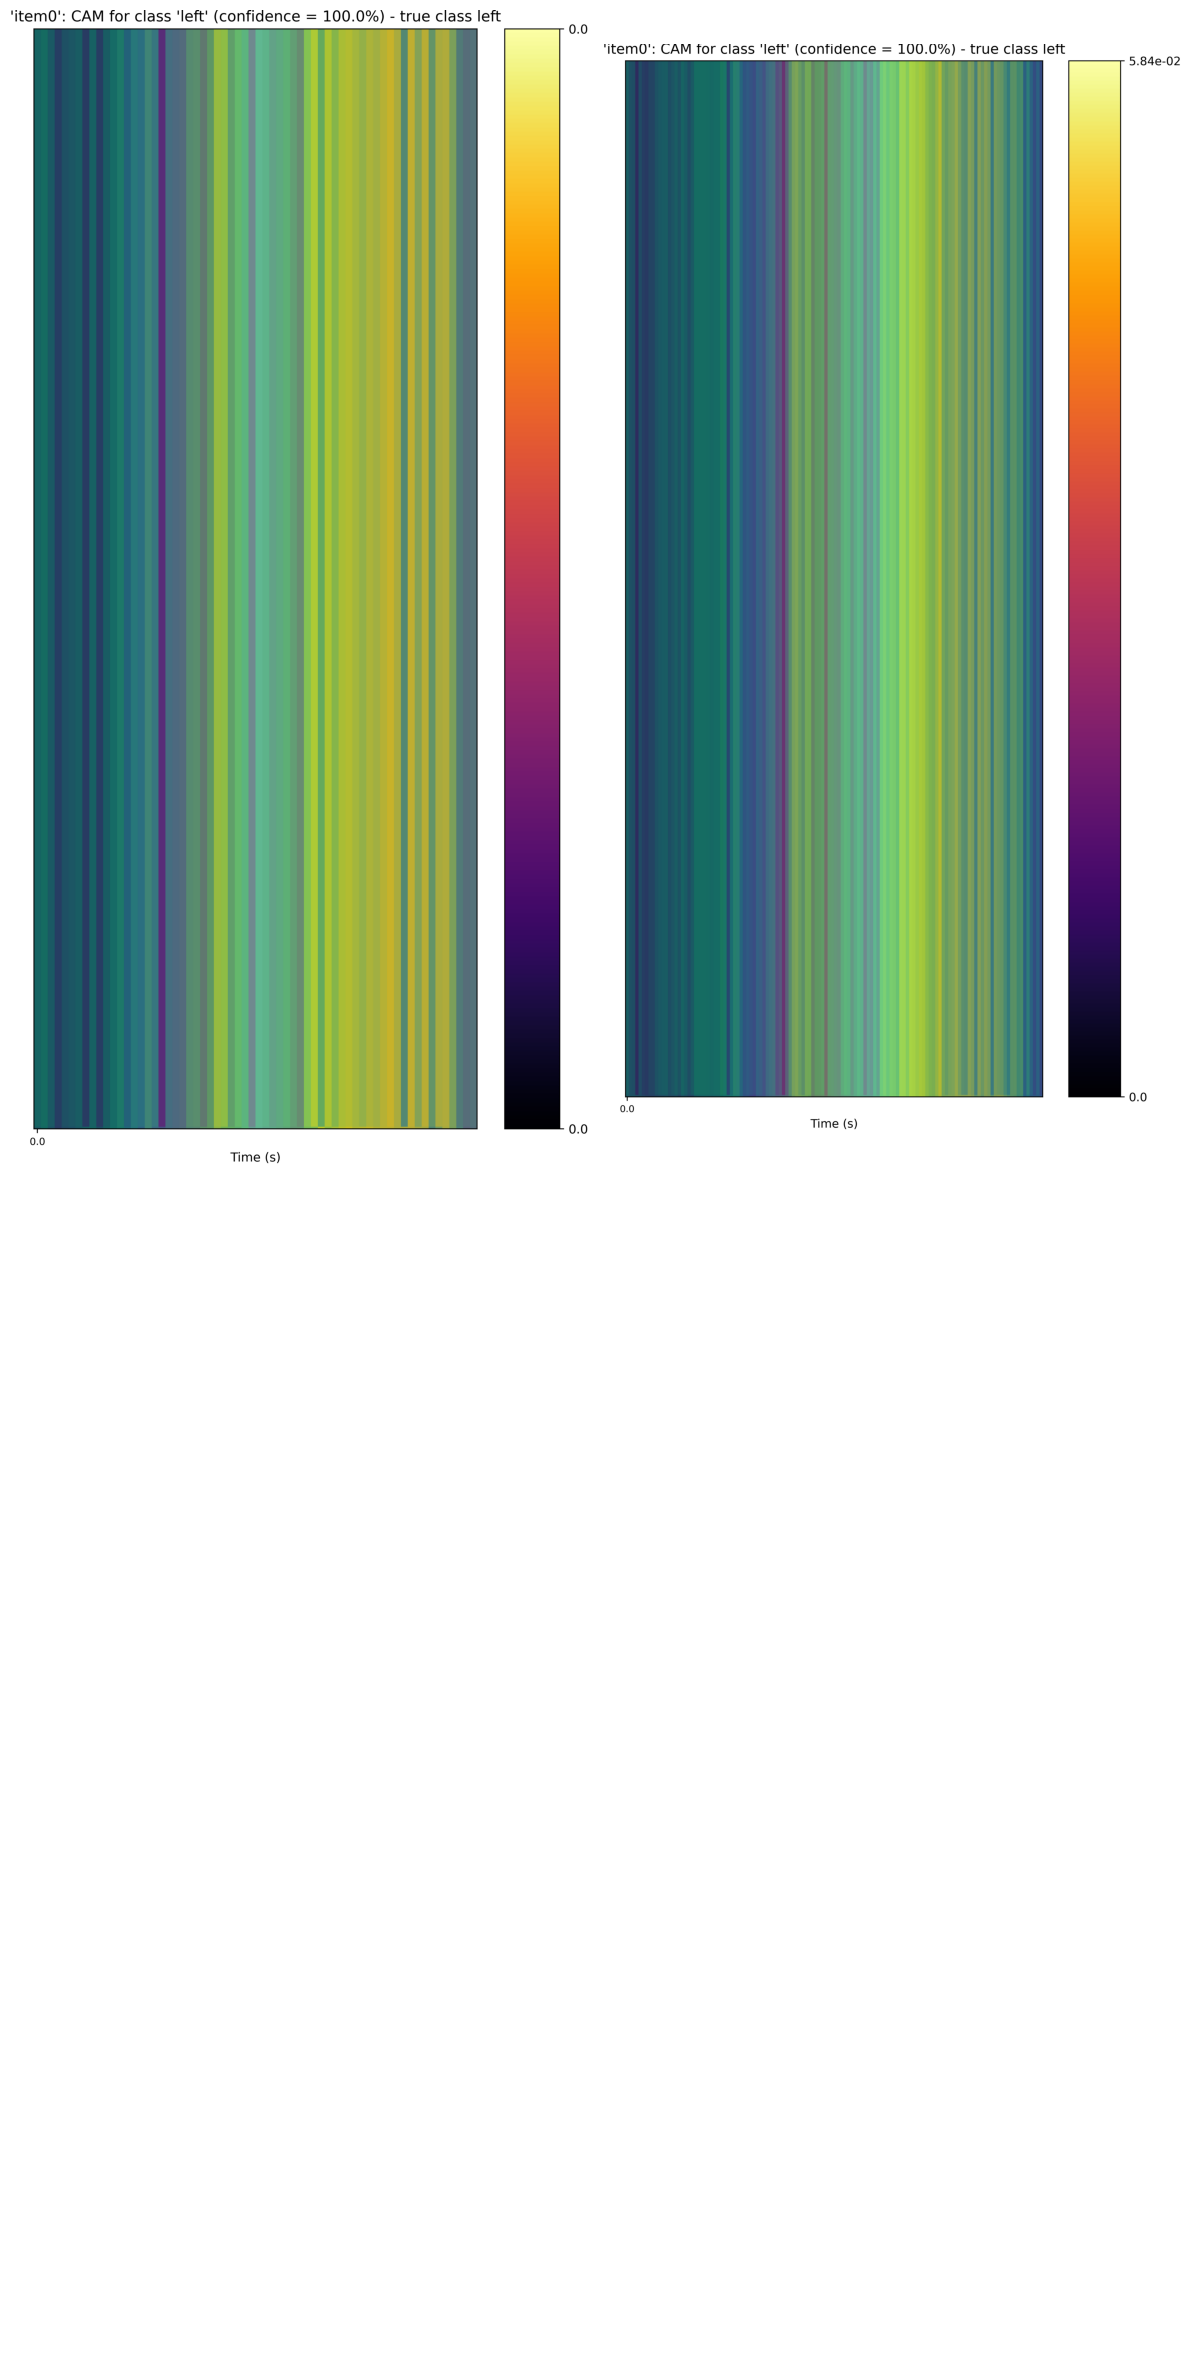

In [19]:
# CAM "LEFT"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

El modelo se adapta bien a estas dimensiones y las métricas son mejores. Se aprecia en los CAMs una mayor resolución, pero sigues sin discriminarse en el eje frecuencial específicamente, sólo como conribución a las ventanas temporales. Observamos ahora HiResCAM:

In [20]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "HiResCAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

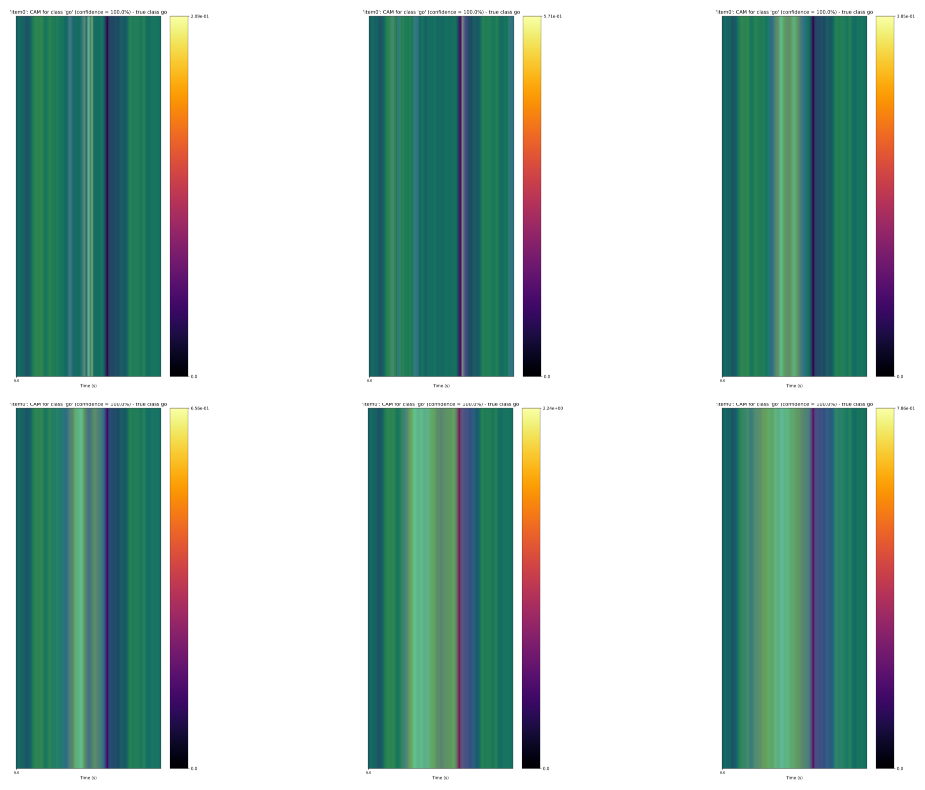

In [21]:
## Visualizamos
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*HiRes*.png"))
show_image_grid(images_to_show)

Finalmente, vamos a estimar el coste de entrenamiento a partir del tiempo medio por epoch.

In [22]:
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
etimes = loaded_pt['history'].get('epoch_time')
avg_etime = sum(etimes)/len(etimes)
print(avg_etime)

529.5453310966492


El coste de entrenamiento se multiplica por 9.41 con respecto de la línea de bas, lo que supone un incremento muy considerable, y más si pensamos en nuestro objetivo de _edge computing_. Aunque las métricas mejoran algo con respecto al experimento anterior no hemos conseguido un cambio claro de la atención del modelo.